图 4-4 (仅 256-bit) 已生成，并保存为 fig4-4_bits_dist_256.png
图 4-4, 4-5 已生成。


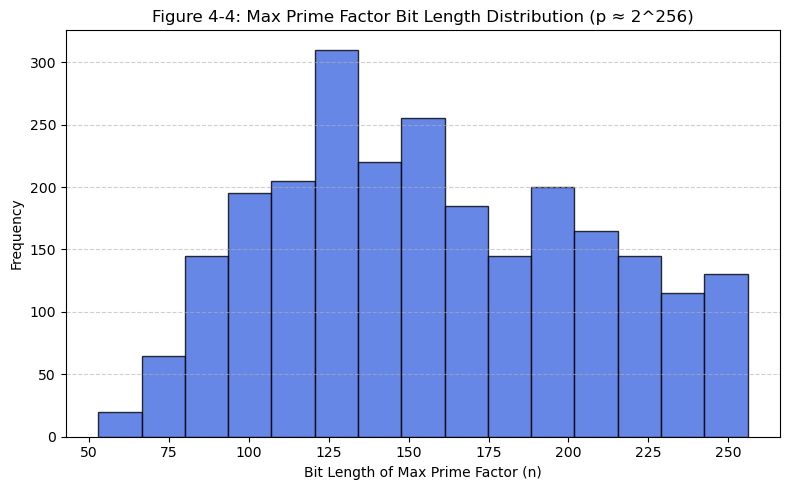

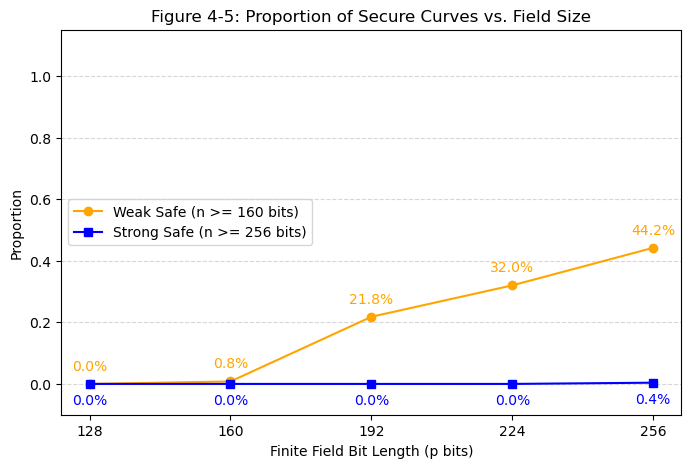

In [2]:
import pickle
import matplotlib.pyplot as plt

with open('ecc_data_merged.pkl', 'rb') as f:
    results = pickle.load(f)

bit_lengths = sorted(results.keys())

# 2. 仅提取 256-bit 的最大素因子比特长度数据
if 256 in results:
    n_bits_256 = [d['n_bits'] for d in results[256]]
    
    # 3. 设置权重：为每个数据点分配权重 10，使纵坐标频数扩大 10 倍
    weights_10 = [5] * len(n_bits_256)

    # 4. 绘图
    plt.figure(figsize=(8, 5))
    
    # bins 建议设为 10-15 之间，能清晰看到 256 附近的集中情况
    plt.hist(n_bits_256, bins=15, weights=weights_10, 
             color='royalblue', edgecolor='black', alpha=0.8)

    # 图表细节美化
    plt.title('Figure 4-4: Max Prime Factor Bit Length Distribution (p ≈ 2^256)')
    plt.xlabel('Bit Length of Max Prime Factor (n)')
    plt.ylabel('Frequency')
    
    # 添加网格线方便阅读
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig('fig4-4_bits_dist_256.png', dpi=300)
    print("图 4-4 (仅 256-bit) 已生成，并保存为 fig4-4_bits_dist_256.png")
else:
    print("错误：数据集中未发现 256-bit 的实验结果，请先运行 generate_data.sage")

# 图 4-5：趋势折线图
# --- 修改 task2_security.py 中图 4-5 的绘图代码 ---
weak_ratios, strong_ratios = [], []
for b in bit_lengths:
    n_bits = [d['n_bits'] for d in results[b]]
    num = len(n_bits)
    weak_ratios.append(sum(1 for l in n_bits if l >= 160) / num)
    strong_ratios.append(sum(1 for l in n_bits if l >= 256) / num)
    
plt.figure(figsize=(8, 5))
plt.plot(bit_lengths, weak_ratios, 'o-', color='orange', label='Weak Safe (n >= 160 bits)')
plt.plot(bit_lengths, strong_ratios, 's-', color='blue', label='Strong Safe (n >= 256 bits)')

# --- 修复后的图 4-5 打标签代码 ---

# 【关键修改】：使用 float(y) 将 SageMath 的分数转为 Python 浮点数
for x, y in zip(bit_lengths, weak_ratios):
    # 坐标和数值都强制转为 float
    plt.annotate(f"{float(y)*100:.1f}%", (x, float(y)), 
                 textcoords="offset points", xytext=(0, 10), ha='center', color='orange')

for x, y in zip(bit_lengths, strong_ratios):
    # 强安全的数据在下方，标签稍微往下偏一点避免重叠
    plt.annotate(f"{float(y)*100:.1f}%", (x, float(y)), 
                 textcoords="offset points", xytext=(0, -15), ha='center', color='blue')
plt.title('Figure 4-5: Proportion of Secure Curves vs. Field Size')
plt.xlabel('Finite Field Bit Length (p bits)')
plt.ylabel('Proportion')
plt.ylim(-0.1, 1.15) # 上下留出空间给标签
plt.xticks(bit_lengths)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='center left') # 将图例移到左侧中间，避免遮挡 256 处的数据
plt.savefig('fig4-5_trend.png', dpi=300)
print("图 4-4, 4-5 已生成。")